# 04 CFPB Time Series: South vs Others (ETS Holt-Winters)

> Objective: Compare quarterly Credit Reporting complaint dynamics for South vs Non-South using the same split framing as 03a/03b and benchmark against aggregate ETS from 03a.

## 1. Data Setup
- Source: `../data/processed/full_dataset.parquet`
- Scope: Product contains `Credit reporting`
- Window: `2012Q4` to `2025Q4`
- Segments: `South` vs `Others`
- Split: fixed `33/10/10` points (train/val/test)

In [1]:
# ============================================================================
# IMPORTS
# ============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot

warnings.filterwarnings("ignore")

In [2]:
# ============================================================================
# LOAD DATA + BUILD QUARTERLY SERIES
# ============================================================================
df = pd.read_parquet('../data/processed/full_dataset.parquet')
df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')
df['yearquarter'] = df['Date received'].dt.to_period('Q').astype(str)

cr_df = df[df['Product'].str.contains('Credit reporting', case=False, na=False)].copy()

full_q_index = pd.period_range('2012Q4', '2025Q4', freq='Q')

def build_series(mask):
    s = (
        cr_df.loc[mask]
        .groupby('yearquarter')
        .size()
        .rename('y')
    )
    s.index = pd.PeriodIndex(s.index, freq='Q')
    s = s.reindex(full_q_index, fill_value=0).astype(float)
    return s

y_south = build_series(cr_df['region'].eq('South'))
y_others = build_series(~cr_df['region'].eq('South'))
y_agg = build_series(pd.Series(True, index=cr_df.index))

print(f'Quarters: {len(full_q_index)} | Range: {full_q_index.min()} -> {full_q_index.max()}')
print(f'South total: {int(y_south.sum()):,}')
print(f'Others total: {int(y_others.sum()):,}')
print(f'Aggregate total: {int(y_agg.sum()):,}')

Quarters: 53 | Range: 2012Q4 -> 2025Q4
South total: 5,642,967
Others total: 4,322,826
Aggregate total: 9,965,793


In [3]:
# ============================================================================
# FIXED SPLITS: 33 / 10 / 10 (MATCH 03a/03b)
# ============================================================================
def make_splits(y):
    train = y.iloc[:33]
    val = y.iloc[33:43]
    test = y.iloc[43:]
    return train, val, test

train_s, val_s, test_s = make_splits(y_south)
train_o, val_o, test_o = make_splits(y_others)
train_a, val_a, test_a = make_splits(y_agg)

print('Split sizes (South):', len(train_s), len(val_s), len(test_s))
print('Split sizes (Others):', len(train_o), len(val_o), len(test_o))
print('Split sizes (Aggregate):', len(train_a), len(val_a), len(test_a))

Split sizes (South): 33 10 10
Split sizes (Others): 33 10 10
Split sizes (Aggregate): 33 10 10


## 2. Helpers (03a-style metrics + plotting + ETS fit)

In [4]:
# ============================================================================
# HELPERS
# ============================================================================
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    ratio = np.where(denom == 0, 0.0, 2.0 * np.abs(y_true - y_pred) / denom)
    return float(100.0 * np.mean(ratio))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

def fit_ets(train, val, test, seasonal=4):
    model = ExponentialSmoothing(
        train,
        seasonal_periods=seasonal,
        trend='add',
        seasonal='add',
        initialization_method='estimated'
    ).fit()
    val_pred = model.forecast(len(val))

    full = pd.concat([train, val])
    test_model = ExponentialSmoothing(
        full,
        seasonal_periods=seasonal,
        trend='add',
        seasonal='add',
        initialization_method='estimated'
    ).fit()
    test_pred = test_model.forecast(len(test))
    return val_pred, test_pred, model, test_model

def plot_section_predictions(section_title, train, val, test, pred_map):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train.index.to_timestamp(how='end'), train.values, color='steelblue', label='Observed - Train')
    ax.plot(val.index.to_timestamp(how='end'), val.values, color='steelblue', linestyle='--', alpha=0.8, label='Observed - Val')
    ax.plot(test.index.to_timestamp(how='end'), test.values, color='steelblue', linestyle=':', alpha=0.9, label='Observed - Test')

    for model_name, preds in pred_map.items():
        val_pred, test_pred = preds
        ax.plot(val.index.to_timestamp(how='end'), np.asarray(val_pred), linestyle='--', marker='o', label=f'{model_name} - Val')
        ax.plot(test.index.to_timestamp(how='end'), np.asarray(test_pred), marker='o', label=f'{model_name} - Test')

    ax.set_title(section_title)
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

## 3. ETS Holt-Winters: South vs Others + Aggregate Benchmark

In [5]:
# ============================================================================
# FIT ETS FOR SOUTH / OTHERS / AGGREGATE
# ============================================================================
val_pred_s, test_pred_s, model_train_s, model_full_s = fit_ets(train_s, val_s, test_s)
val_pred_o, test_pred_o, model_train_o, model_full_o = fit_ets(train_o, val_o, test_o)
val_pred_a, test_pred_a, model_train_a, model_full_a = fit_ets(train_a, val_a, test_a)

results = pd.DataFrame([
    {
        'Group': 'South',
        'sMAPE_val': smape(val_s.values, val_pred_s.values),
        'MAE_val': mae(val_s.values, val_pred_s.values),
        'RMSE_val': rmse(val_s.values, val_pred_s.values),
        'sMAPE_test': smape(test_s.values, test_pred_s.values),
        'MAE_test': mae(test_s.values, test_pred_s.values),
        'RMSE_test': rmse(test_s.values, test_pred_s.values)
    },
    {
        'Group': 'Others',
        'sMAPE_val': smape(val_o.values, val_pred_o.values),
        'MAE_val': mae(val_o.values, val_pred_o.values),
        'RMSE_val': rmse(val_o.values, val_pred_o.values),
        'sMAPE_test': smape(test_o.values, test_pred_o.values),
        'MAE_test': mae(test_o.values, test_pred_o.values),
        'RMSE_test': rmse(test_o.values, test_pred_o.values)
    },
    {
        'Group': 'Aggregate (03a benchmark style)',
        'sMAPE_val': smape(val_a.values, val_pred_a.values),
        'MAE_val': mae(val_a.values, val_pred_a.values),
        'RMSE_val': rmse(val_a.values, val_pred_a.values),
        'sMAPE_test': smape(test_a.values, test_pred_a.values),
        'MAE_test': mae(test_a.values, test_pred_a.values),
        'RMSE_test': rmse(test_a.values, test_pred_a.values)
    }
])

for c in ['sMAPE_val', 'MAE_val', 'RMSE_val', 'sMAPE_test', 'MAE_test', 'RMSE_test']:
    results[c] = results[c].round(3)

display(results)

delta = pd.DataFrame({
    'Comparison': ['South - Others', 'South - Aggregate', 'Others - Aggregate'],
    'Delta_sMAPE_test': [
        smape(test_s.values, test_pred_s.values) - smape(test_o.values, test_pred_o.values),
        smape(test_s.values, test_pred_s.values) - smape(test_a.values, test_pred_a.values),
        smape(test_o.values, test_pred_o.values) - smape(test_a.values, test_pred_a.values),
    ]
}).round(3)
display(delta)

,Group,sMAPE_val,MAE_val,RMSE_val,sMAPE_test,MAE_test,RMSE_test
0,South,34.746,24448.519,27119.616,55.842,238973.858,320912.767
1,Others,32.676,19656.670,21823.124,48.959,153767.458,195151.302
2,Aggregate (03a benchmark style),31.936,40498.235,46249.166,51.760,386621.007,508033.338


,Comparison,Delta_sMAPE_test
0,South - Others,6.883
1,South - Aggregate,4.082
2,Others - Aggregate,-2.801


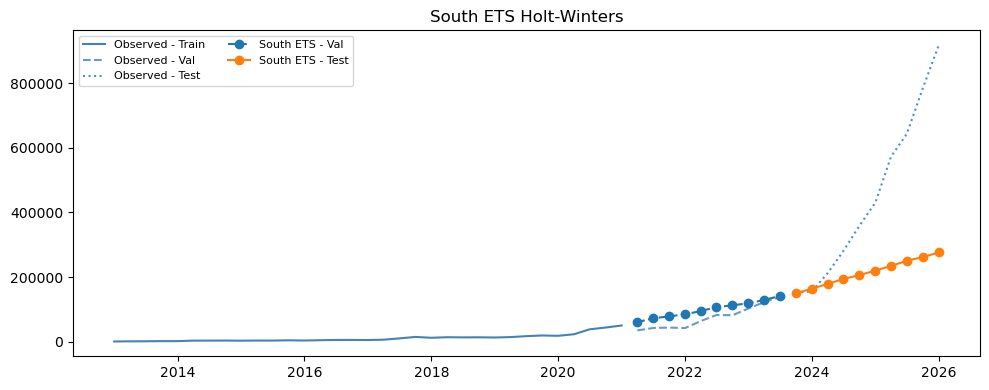

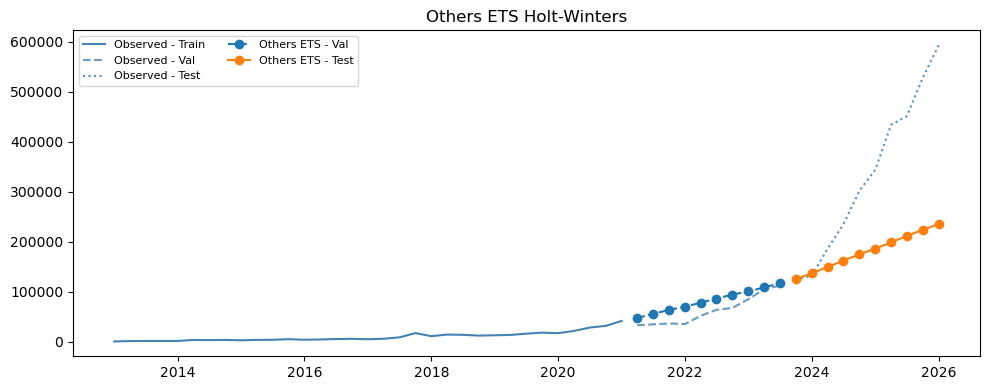

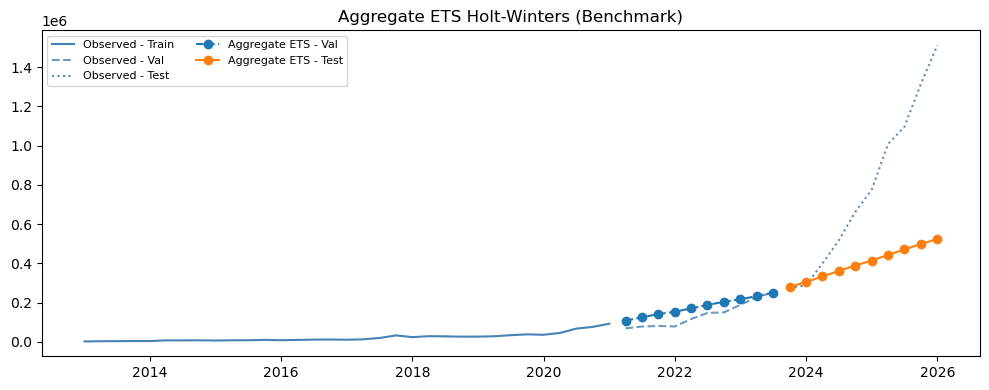

In [6]:
# ============================================================================
# PLOTS: FORECAST COMPARISON
# ============================================================================
plot_section_predictions('South ETS Holt-Winters', train_s, val_s, test_s, {'South ETS': (val_pred_s, test_pred_s)})
plot_section_predictions('Others ETS Holt-Winters', train_o, val_o, test_o, {'Others ETS': (val_pred_o, test_pred_o)})
plot_section_predictions('Aggregate ETS Holt-Winters (Benchmark)', train_a, val_a, test_a, {'Aggregate ETS': (val_pred_a, test_pred_a)})

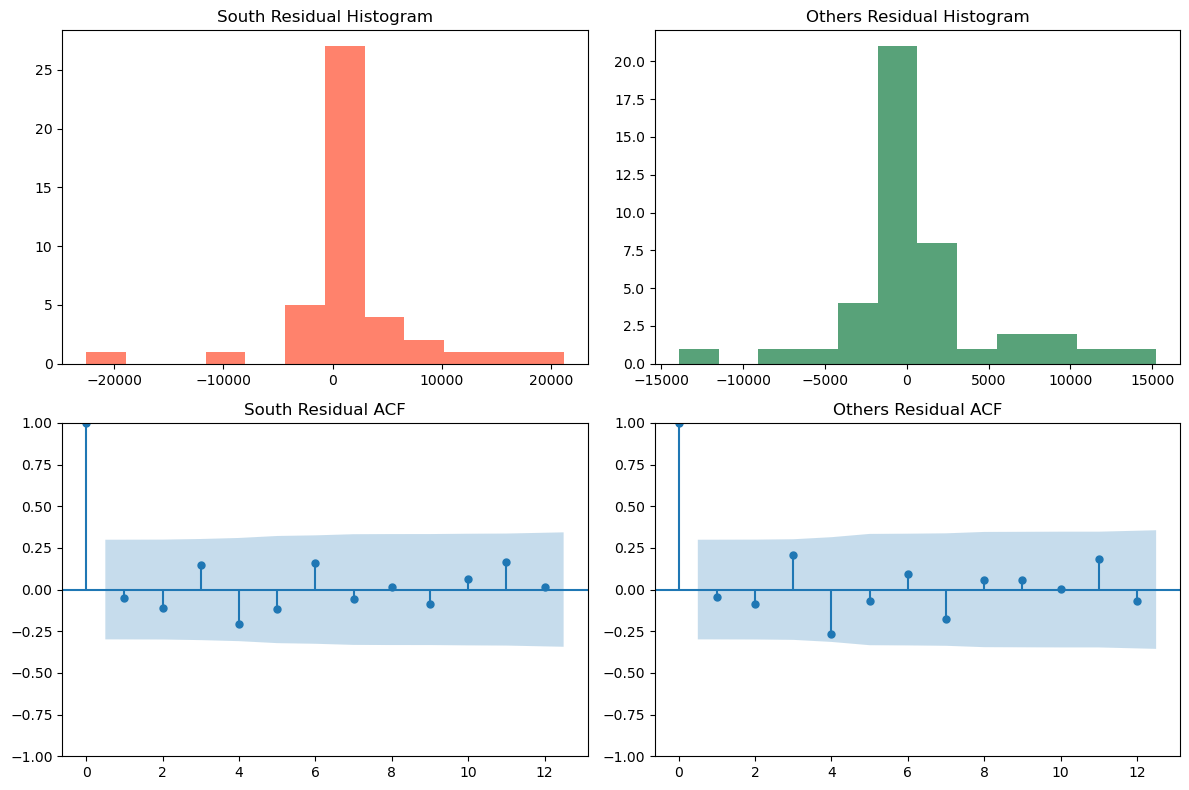

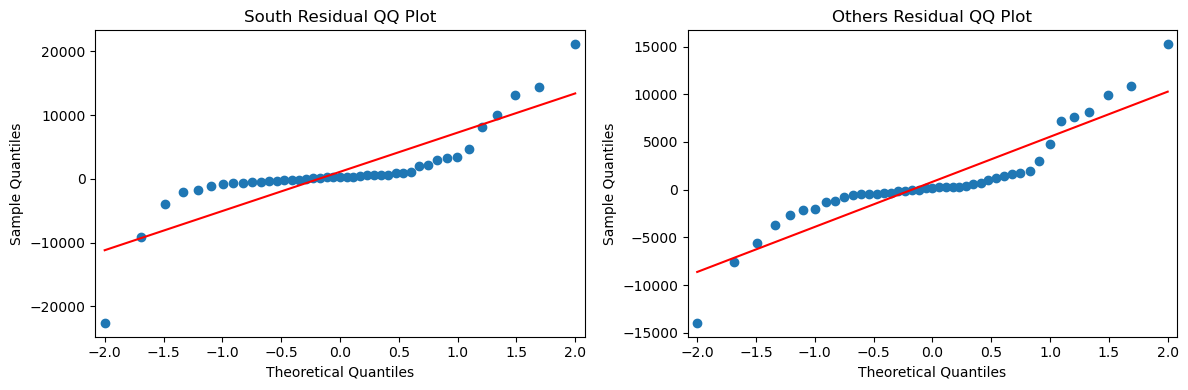

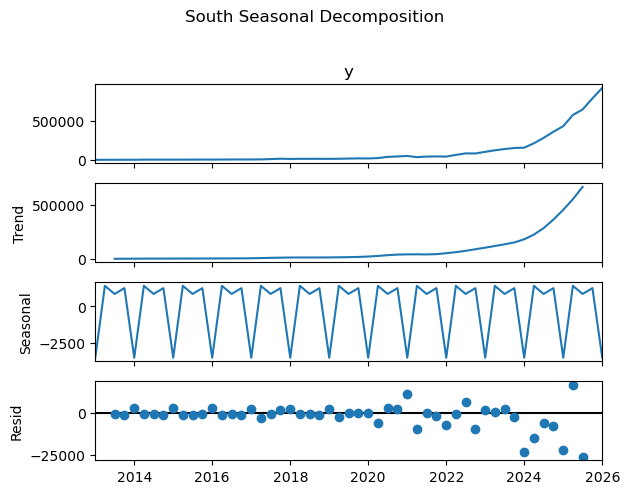

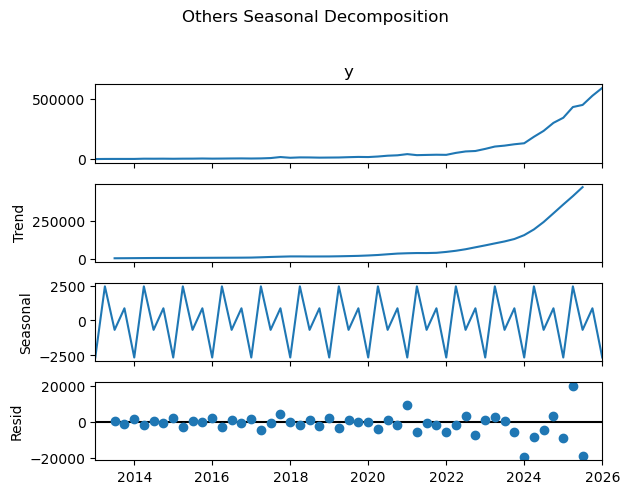

In [8]:
# ============================================================================
# DIAGNOSTICS: RESIDUALS, ACF, QQ, SEASONAL DECOMPOSITION
# ============================================================================
south_resid = pd.Series(model_full_s.resid).dropna()
others_resid = pd.Series(model_full_o.resid).dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].hist(south_resid, bins=12, alpha=0.8, color='tomato')
axes[0, 0].set_title('South Residual Histogram')
axes[0, 1].hist(others_resid, bins=12, alpha=0.8, color='seagreen')
axes[0, 1].set_title('Others Residual Histogram')

plot_acf(south_resid, lags=min(12, len(south_resid)-1), ax=axes[1, 0])
axes[1, 0].set_title('South Residual ACF')
plot_acf(others_resid, lags=min(12, len(others_resid)-1), ax=axes[1, 1])
axes[1, 1].set_title('Others Residual ACF')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
qqplot(south_resid, line='s', ax=axes[0])
axes[0].set_title('South Residual QQ Plot')
qqplot(others_resid, line='s', ax=axes[1])
axes[1].set_title('Others Residual QQ Plot')
plt.tight_layout()
plt.show()

south_series_ts = pd.concat([train_s, val_s, test_s]).copy()
south_series_ts.index = south_series_ts.index.to_timestamp(how='end')
others_series_ts = pd.concat([train_o, val_o, test_o]).copy()
others_series_ts.index = others_series_ts.index.to_timestamp(how='end')

decomp_s = seasonal_decompose(south_series_ts, model='additive', period=4)
decomp_o = seasonal_decompose(others_series_ts, model='additive', period=4)

_ = decomp_s.plot()
plt.suptitle('South Seasonal Decomposition', y=1.02)
plt.tight_layout()
plt.show()

_ = decomp_o.plot()
plt.suptitle('Others Seasonal Decomposition', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# ============================================================================
# SAVE MODELS + TABLE OUTPUTS
# ============================================================================
model_dir = '../models'
table_dir = '../reports/2026-03-25/tables'
os.makedirs(model_dir, exist_ok=True)
os.makedirs(table_dir, exist_ok=True)

south_model_path = f'{model_dir}/04_south_ets.pkl'
others_model_path = f'{model_dir}/04_others_ets.pkl'
agg_model_path = f'{model_dir}/04_aggregate_ets.pkl'

model_full_s.save(south_model_path)
model_full_o.save(others_model_path)
model_full_a.save(agg_model_path)

results_path = f'{table_dir}/04_south_vs_others_ets_results.csv'
delta_path = f'{table_dir}/04_south_vs_others_ets_delta.csv'
results.to_csv(results_path, index=False)
delta.to_csv(delta_path, index=False)

print('Saved:', south_model_path)
print('Saved:', others_model_path)
print('Saved:', agg_model_path)
print('Saved results:', results_path)
print('Saved deltas:', delta_path)

Saved: ../models/04_south_ets.pkl
Saved: ../models/04_others_ets.pkl
Saved: ../models/04_aggregate_ets.pkl
Saved results: ../reports/2026-03-25/tables/04_south_vs_others_ets_results.csv
Saved deltas: ../reports/2026-03-25/tables/04_south_vs_others_ets_delta.csv


In [10]:
# ============================================================================
# AUTO BUSINESS SUMMARY (DECISION FLAG)
# ============================================================================
threshold = 5.0  # percentage-point gap in sMAPE_test for intervention priority
delta_south_vs_others = float(delta.loc[delta['Comparison'] == 'South - Others', 'Delta_sMAPE_test'].iloc[0])

south_row = results.loc[results['Group'] == 'South'].iloc[0]
others_row = results.loc[results['Group'] == 'Others'].iloc[0]
agg_row = results.loc[results['Group'] == 'Aggregate (03a benchmark style)'].iloc[0]

priority_flag = delta_south_vs_others > threshold

print('=== BUSINESS SUMMARY ===')
print(f"South sMAPE_test:   {south_row['sMAPE_test']:.3f}")
print(f"Others sMAPE_test:  {others_row['sMAPE_test']:.3f}")
print(f"Aggregate sMAPE_test: {agg_row['sMAPE_test']:.3f}")
print(f"Delta (South - Others): {delta_south_vs_others:.3f} pp")

if priority_flag:
    print(f"Priority flag: YES (gap > {threshold:.1f} pp). South underperforms Others and may need targeted intervention.")
else:
    print(f"Priority flag: NO (gap <= {threshold:.1f} pp). No strong evidence of segment-specific underperformance.")

runtime_proxy = pd.DataFrame({
    'Group': ['South', 'Others', 'Aggregate'],
    'TrainPoints': [len(train_s), len(train_o), len(train_a)],
    'ValPoints': [len(val_s), len(val_o), len(val_a)],
    'TestPoints': [len(test_s), len(test_o), len(test_a)]
})
display(runtime_proxy)

=== BUSINESS SUMMARY ===
South sMAPE_test:   55.842
Others sMAPE_test:  48.959
Aggregate sMAPE_test: 51.760
Delta (South - Others): 6.883 pp
Priority flag: YES (gap > 5.0 pp). South underperforms Others and may need targeted intervention.


,Group,TrainPoints,ValPoints,TestPoints
0,South,33,10,10
1,Others,33,10,10
2,Aggregate,33,10,10


## 3.1 Full-History ETS Forward Forecast

This section mirrors the 03a baseline style: each segment model is fit on the full available history (no train/val/test split) and forecasts the next 4 quarters directly.

4-quarter forward forecast (full-history ETS):


,South_ETS,Others_ETS
2026Q1,1074528.6,677480.9
2026Q2,1199219.2,728521.7
2026Q3,1349262.8,809736.4
2026Q4,1474550.0,868112.9


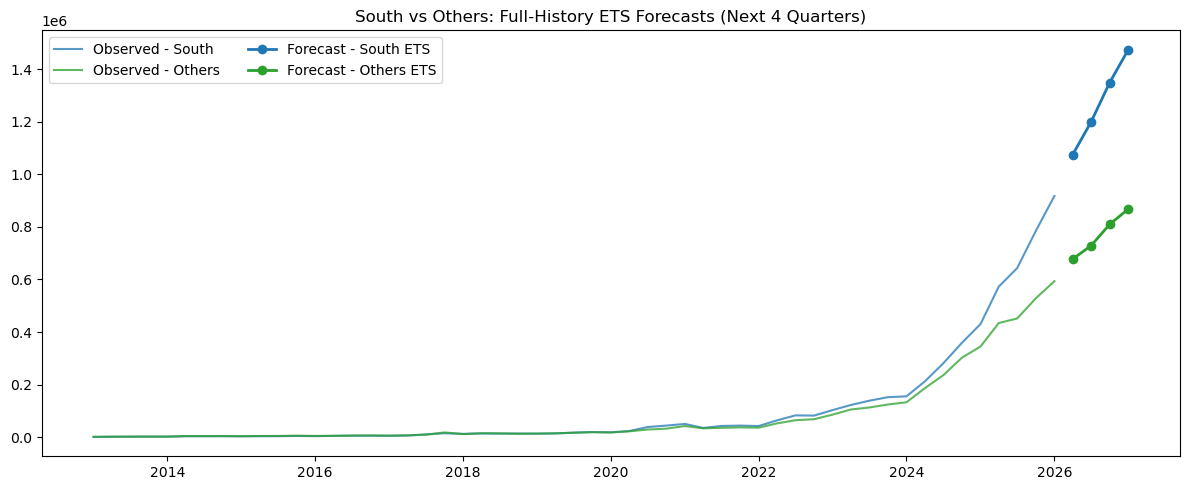

In [11]:
# ============================================================================
# FULL-HISTORY FORECAST (NO TRAIN/VAL/TEST SPLIT)
# ============================================================================
h = 4
future_q = pd.period_range(start=full_q_index[-1] + 1, periods=h, freq="Q")

ets_full_s = ExponentialSmoothing(
    y_south, trend="add", seasonal="add", seasonal_periods=4, initialization_method="estimated"
).fit(optimized=True)
ets_full_o = ExponentialSmoothing(
    y_others, trend="add", seasonal="add", seasonal_periods=4, initialization_method="estimated"
).fit(optimized=True)

fc_south_4q = ets_full_s.forecast(h)
fc_others_4q = ets_full_o.forecast(h)

forward_tbl = pd.DataFrame({
    "South_ETS": np.round(fc_south_4q.values, 1),
    "Others_ETS": np.round(fc_others_4q.values, 1)
}, index=future_q.astype(str))

print("4-quarter forward forecast (full-history ETS):")
display(forward_tbl)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    y_south.index.to_timestamp(how="end"),
    y_south.values,
    color="tab:blue",
    alpha=0.75,
    label="Observed - South"
)
ax.plot(
    y_others.index.to_timestamp(how="end"),
    y_others.values,
    color="tab:green",
    alpha=0.75,
    label="Observed - Others"
)

future_ts = future_q.to_timestamp(how="end")
ax.plot(future_ts, fc_south_4q.values, marker="o", color="tab:blue", linewidth=2, label="Forecast - South ETS")
ax.plot(future_ts, fc_others_4q.values, marker="o", color="tab:green", linewidth=2, label="Forecast - Others ETS")

ax.set_title("South vs Others: Full-History ETS Forecasts (Next 4 Quarters)")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

## 4. Business Insights Checklist
- Compare `sMAPE_test` deltas to prioritize intervention by region segment.
- Check whether South residual ACF indicates stronger unmodeled autocorrelation.
- If South error is materially higher, consider segment-specific feature engineering in 05+ (policy/event regressors).
- Use saved ETS artifacts as deterministic classical benchmarks before trying higher-capacity models.

## 5. Conclusion

This notebook evaluated ETS Holt-Winters behavior for CFPB Credit Reporting complaints across South, Others, and the aggregate series under a consistent quarterly framing.

### Summary of Results
- In holdout evaluation, South underperformed Others on test sMAPE, indicating a harder regional forecasting profile.
- The gap in test error was large enough to trigger a practical priority flag for South-focused monitoring.
- The aggregate benchmark remained useful as a portfolio reference point, but segment-level modeling gave clearer operational insight.

### Forward-Looking View
- Full-history ETS forecasts for the next 4 quarters show continued growth in both segments.
- South remains higher-volume and steeper in projected level, reinforcing the need for dedicated segment tracking.

### Practical Takeaway
- Use split-based metrics when model comparison and validation rigor are required.
- Use full-history ETS forecasts for planning-oriented projections once the model family is selected.
- Keep South and Others as separate reporting lines in downstream analyses and intervention planning.